In [48]:
# Load packages
from costs_benefits_ssp.cb_calculate import CostBenefits
import pandas as pd
import os
import pathlib
import numpy as np
import warnings

In [49]:
##---- Define Directories ----##
SCRIPT_DIR_PATH = os.getcwd()
PARENT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
OUTPUT_CB_PATH = os.path.join(SCRIPT_DIR_PATH, "out")
CONFIG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "cb_config_files")
RUN_OUTPUT_DIR_PATH = os.path.join(PARENT_DIR_PATH, "ssp_run_output")
RUN_ID = "sisepuede_results_sisepuede_run_2026-04-14T18;19;35.543642"
RUN_DIR_PATH = os.path.join(RUN_OUTPUT_DIR_PATH, RUN_ID )   
DIF_OUTPUT_FILE = os.path.join(PARENT_DIR_PATH,"tableau/data")

In [50]:
RUN_DIR_PATH

'/Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2026-04-14T18;19;35.543642'

In [51]:
# Make sure output directory exists
os.makedirs(OUTPUT_CB_PATH, exist_ok=True)

In [52]:
## Load the data
ssp_data = pd.read_csv(os.path.join(RUN_DIR_PATH, "decomposed_ssp_output.csv"))
att_primary = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))
att_strategy = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_STRATEGY.csv"))
print(f"Loaded ssp_data with {ssp_data.shape[0]} rows and {ssp_data.shape[1]} columns")
print(f"Loaded att_primary with {att_primary.shape[0]} rows and {att_primary.shape[1]} columns")
print(f"Loaded att_strategy with {att_strategy.shape[0]} rows and {att_strategy.shape[1]} columns")

Loaded ssp_data with 112 rows and 4107 columns
Loaded att_primary with 4 rows and 4 columns
Loaded att_strategy with 133 rows and 6 columns


In [53]:
att_strategy.head()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0


In [54]:
att_strategy.head()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0


In [55]:
## Define base strategy
strategy_code_base = "BASE"

In [56]:
# Check if strategy_code_base exists in att_strategy
if strategy_code_base not in att_strategy['strategy_code'].values:
    raise ValueError(f"Base strategy code '{strategy_code_base}' not found in att_strategy.")

In [57]:
## Instantiate an object of the CostBenefits class
cb = CostBenefits(ssp_data, att_primary, att_strategy, strategy_code_base)

In [58]:
# Once the excel file has been updated, we can reload it to update the cost factors database
cb.load_cb_parameters(os.path.join(CONFIG_DIR_PATH, "cb_config_params.xlsx"))   

Loading configuration from Excel file (fast path)
Database updated


In [59]:
# Compute System Costs
results_system = cb.compute_system_cost_for_all_strategies()


************************************
*Strategy : PFLO:BAU (0/3)
************************************

---------Costs for: cb:agrc:crop_value:crops_produced:bevs_and_spices.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:cereals.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:fibers.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:fruits.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:herbs.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:nuts.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:other_annual.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:other_woody_perennial.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_

In [60]:
# Compute Technical Costs
results_tx = cb.compute_technical_cost_for_all_strategies()


************************************
*Strategy : PFLO:BAU (0/3)
************************************

---------Costs for: cb:lsmm:technical_cost:manure_management_cattle_pigs.
The variable is evaluated in Transformation Cost
---------Costs for: cb:lvst:technical_cost:ent_ferm_mgmt:X.
The variable is evaluated in Transformation Cost

************************************
*Strategy : PFLO:UNCONDITIONAL (1/3)
************************************

---------Costs for: cb:agrc:consumer_savings:cons_ag_land_value:X.
The variable is evaluated in Transformation Cost
---------Costs for: cb:agrc:technical_cost:producer_food_waste:X.
The variable is evaluated in Transformation Cost
---------Costs for: cb:agrc:technical_savings:cons_ag:X.
The variable is evaluated in Transformation Cost
---------Costs for: cb:agrc:technical_savings:producer_food_waste:X.
The variable is evaluated in Transformation Cost
---------Costs for: cb:entc:technical_cost:loss_reduction:electricity.
The variable is evaluated 

In [61]:
# Combine results
results_all = pd.concat([results_system, results_tx], ignore_index = True)

In [62]:
#-------------POST PROCESS SIMULATION RESULTS---------------
# Post process interactions among strategies that affect the same variables
results_all_pp = cb.cb_process_interactions(results_all)

# SHIFT any stray costs incurred from 2015 to 2025 to 2025 and 2035
results_all_pp_shifted = cb.cb_shift_costs(results_all_pp)


Resolving Interactions in SCOE :  
No interactions, skipping... PFLO:BAU
Resolving Interactions in INEN :  
No interactions, skipping... PFLO:BAU
Resolving Interactions in SCOE : TX:SCOE:INC_EFFICIENCY_APPLIANCE, TX:SCOE:DEC_DEMAND_HEAT 
Resolving Interactions in INEN : TX:INEN:INC_EFFICIENCY_ENERGY 
Resolving Interactions in SCOE : TX:SCOE:INC_EFFICIENCY_APPLIANCE, TX:SCOE:DEC_DEMAND_HEAT 
Resolving Interactions in INEN : TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:INC_EFFICIENCY_ENERGY 


In [63]:
results_all_pp

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value
0,PFLO:BAU,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000e+00
1,PFLO:BAU,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000e+00
2,PFLO:BAU,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000e+00
3,PFLO:BAU,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000e+00
4,PFLO:BAU,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
21751,PFLO:CONDITIONAL,0.0,libya,31.0,energy_consumption_inen_total,115.785731,68.555697,-47.230034,cb:inen:technical_savings:fuel_switch:lo_heat,3.938985e+06
21752,PFLO:CONDITIONAL,0.0,libya,32.0,energy_consumption_inen_total,115.430881,67.759907,-47.670974,cb:inen:technical_savings:fuel_switch:lo_heat,3.975759e+06
21753,PFLO:CONDITIONAL,0.0,libya,33.0,energy_consumption_inen_total,115.073795,67.106440,-47.967355,cb:inen:technical_savings:fuel_switch:lo_heat,4.000477e+06
21754,PFLO:CONDITIONAL,0.0,libya,34.0,energy_consumption_inen_total,114.714538,66.591505,-48.123032,cb:inen:technical_savings:fuel_switch:lo_heat,4.013461e+06


In [64]:
results_all_pp.strategy_code.unique()

array(['PFLO:BAU', 'PFLO:UNCONDITIONAL', 'PFLO:CONDITIONAL'], dtype=object)

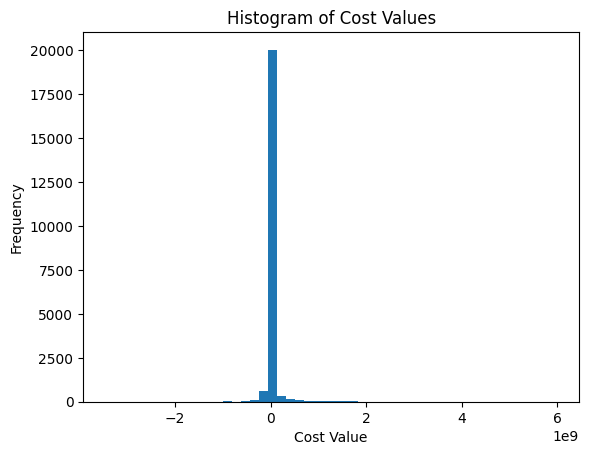

In [65]:
import matplotlib.pyplot as plt
plt.hist(results_all_pp.value, bins=50)
plt.title('Histogram of Cost Values')
plt.xlabel('Cost Value')
plt.ylabel('Frequency')
plt.show()

## Check for NaNs and Infs and DF Cleaning

In [66]:
# check nans
results_all_pp.value.isna().any()

np.False_

In [67]:
# check -inf or inf values
results_all_pp.value.isin([float('inf'), float('-inf')]).any()

np.False_

In [68]:
OUTPUT_CB_PATH

'/Users/fabianfuentes/git/ssp_libya/ssp_modeling/cost-benefits/out'

In [69]:
results_all_pp.to_csv(os.path.join(OUTPUT_CB_PATH, "cost_benefits_results.csv"), index=False)

## Reshape to load into tableau

In [70]:
# --- Read cost-benefit data ---
cb_data = results_all_pp.copy()

# Split 'variable' into components: name, sector, cb_type, item_1, item_2
# (Assumes exactly 5 colon-separated parts; if there are more colons inside the last field,
# they will be kept in item_2 thanks to n=4)
cb_chars = cb_data["variable"].astype(str).str.split(":", n=4, expand=True)
cb_chars.columns = ["name", "sector", "cb_type", "item_1", "item_2"]
cb_data = pd.concat([cb_data, cb_chars], axis=1)

In [71]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2
0,PFLO:BAU,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
1,PFLO:BAU,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
2,PFLO:BAU,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
3,PFLO:BAU,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
4,PFLO:BAU,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices


In [72]:
# Scale value from USD to billions (divide by 1e9)
if "value" in cb_data.columns:
    cb_data["value"] = cb_data["value"] / 1e9

# --- Remove "shifted" entries ---
# Remove rows where item_2 contains "shifted"
cb_data = cb_data[~cb_data["item_2"].astype(str).str.contains("shifted", na=False)]

# Remove any remaining rows where variable contains "shifted2"
cb_data = cb_data[~cb_data["variable"].astype(str).str.contains("shifted2", na=False)]

# --- Add Year column (Year = time_period + 2015) ---
cb_data["Year"] = cb_data["time_period"] + 2015

**This Section Needs Manual Tunnning**

In [73]:
cb_data.strategy_code.unique()

array(['PFLO:BAU', 'PFLO:UNCONDITIONAL', 'PFLO:CONDITIONAL'], dtype=object)

In [74]:
# Harmonize strategy name changes with a single mapping (no duplicate replacements)
strategy_name_map = {
    "PFLO:BAU": "Business as Usual",
    "PFLO:UNCONDITIONAL": "Unconditional",
    "PFLO:CONDITIONAL": "Conditional",
}

cb_data["strategy"] = (
    cb_data["strategy_code"].astype(str).map(strategy_name_map).fillna(cb_data["strategy_code"])
)
print(cb_data["strategy"].unique())


['Business as Usual' 'Unconditional' 'Conditional']


In [75]:
# --- Strategy ID mapping based on strategy_code ---
def map_strategy_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:BAU":
        return 6003
    if code == "PFLO:UNCONDITIONAL":
        return 6004
    if code == "PFLO:CONDITIONAL":
        return 6005
    return code  # keep original if not matched

cb_data["strategy_id"] = cb_data["strategy_code"].astype(str).map(map_strategy_id)

In [76]:
ssp_data.primary_id.unique()

array([    0, 74074, 75075, 76076])

In [77]:
ssp_data

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,yf_agrc_herbs_and_other_perennial_crops_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_other_annual_tonne_ha,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_pulses_tonne_ha,yf_agrc_rice_tonne_ha,yf_agrc_sugar_cane_tonne_ha,yf_agrc_tubers_tonne_ha,yf_agrc_vegetables_and_vines_tonne_ha,yf_lndu_supremum_pastures_tonne_per_ha
0,0,libya,8,0,4.035087e+06,0,3.088256e+06,0,737827.582324,2.579297e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
1,0,libya,9,0,4.186683e+06,0,3.204280e+06,0,765547.399674,2.676199e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
2,0,libya,10,0,4.306798e+06,0,3.296210e+06,0,787510.787871,2.752979e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
3,0,libya,11,0,4.401839e+06,0,3.368950e+06,0,804889.323997,2.813731e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
4,0,libya,12,0,4.476885e+06,0,3.426386e+06,0,818611.693756,2.861702e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,76076,libya,31,0,4.659100e+06,0,3.565845e+06,0,851930.274808,2.978177e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
108,76076,libya,32,0,4.651115e+06,0,3.559733e+06,0,850470.081069,2.973072e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
109,76076,libya,33,0,4.642767e+06,0,3.553344e+06,0,848943.678965,2.967736e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
110,76076,libya,34,0,4.634106e+06,0,3.546716e+06,0,847360.000884,2.962200e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81


In [78]:
def map_primary_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:BAU":
        return 74074
    if code == "PFLO:UNCONDITIONAL":
        return 75075
    if code == "PFLO:CONDITIONAL":
        return 76076
    return code  # keep original if not matched

cb_data["primary_id"] = cb_data["strategy_code"].astype(str).map(map_primary_id)


**Manual Tunning Ends Here**

In [79]:
# --- Create ids (variable:strategy_id) ---
cb_data["ids"] = cb_data["variable"].astype(str) + ":" + cb_data["strategy_id"].astype(str)

In [80]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids
0,PFLO:BAU,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2023.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...
1,PFLO:BAU,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2024.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...
2,PFLO:BAU,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2025.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...
3,PFLO:BAU,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2026.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...
4,PFLO:BAU,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2027.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...


In [81]:
cb_data.strategy.unique()

array(['Business as Usual', 'Unconditional', 'Conditional'], dtype=object)

In [82]:
cb_data.strategy_code.unique()

array(['PFLO:BAU', 'PFLO:UNCONDITIONAL', 'PFLO:CONDITIONAL'], dtype=object)

In [83]:
# --- Read GDP and merge ---
# Keep only needed columns
gdp = ssp_data.loc[:, ["primary_id", "time_period", "gdp_mmm_usd"]]
gdp.head(100)

,primary_id,time_period,gdp_mmm_usd
0,0,8,101.162039
1,0,9,105.576742
2,0,10,107.688276
3,0,11,109.842042
4,0,12,112.038883
...,...,...,...
95,76076,19,128.697459
96,76076,20,131.271408
97,76076,21,133.896836
98,76076,22,136.574773


In [84]:
gdp[gdp['primary_id']== 76076]

,primary_id,time_period,gdp_mmm_usd
84,76076,8,101.162039
85,76076,9,105.576742
86,76076,10,107.688276
87,76076,11,109.842042
88,76076,12,112.038883
89,76076,13,114.279660
90,76076,14,116.565254
91,76076,15,118.896559
92,76076,16,121.274490
93,76076,17,123.699980


In [85]:
# Merge cb_data with gdp on primary_id and time_period
cb_data = cb_data.merge(gdp, on=["primary_id", "time_period"], how="left")
cb_data

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,...,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids,gdp_mmm_usd
0,PFLO:BAU,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2023.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...,101.162039
1,PFLO:BAU,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2024.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...,105.576742
2,PFLO:BAU,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2025.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...,107.688276
3,PFLO:BAU,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2026.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...,109.842042
4,PFLO:BAU,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2027.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...,112.038883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21751,PFLO:CONDITIONAL,0.0,libya,31.0,energy_consumption_inen_total,115.785731,68.555697,-47.230034,cb:inen:technical_savings:fuel_switch:lo_heat,0.003939,...,inen,technical_savings,fuel_switch,lo_heat,2046.0,Conditional,6005,76076,cb:inen:technical_savings:fuel_switch:lo_heat:...,163.219496
21752,PFLO:CONDITIONAL,0.0,libya,32.0,energy_consumption_inen_total,115.430881,67.759907,-47.670974,cb:inen:technical_savings:fuel_switch:lo_heat,0.003976,...,inen,technical_savings,fuel_switch,lo_heat,2047.0,Conditional,6005,76076,cb:inen:technical_savings:fuel_switch:lo_heat:...,166.483886
21753,PFLO:CONDITIONAL,0.0,libya,33.0,energy_consumption_inen_total,115.073795,67.106440,-47.967355,cb:inen:technical_savings:fuel_switch:lo_heat,0.004000,...,inen,technical_savings,fuel_switch,lo_heat,2048.0,Conditional,6005,76076,cb:inen:technical_savings:fuel_switch:lo_heat:...,169.813564
21754,PFLO:CONDITIONAL,0.0,libya,34.0,energy_consumption_inen_total,114.714538,66.591505,-48.123032,cb:inen:technical_savings:fuel_switch:lo_heat,0.004013,...,inen,technical_savings,fuel_switch,lo_heat,2049.0,Conditional,6005,76076,cb:inen:technical_savings:fuel_switch:lo_heat:...,173.209835


In [86]:
cb_data.isna().sum()

strategy_code                0
future_id                    0
region                       0
time_period                  0
difference_variable          0
variable_value_baseline      0
variable_value_pathway     168
difference_value             0
variable                     0
value                        0
name                         0
sector                       0
cb_type                      0
item_1                       0
item_2                     616
Year                         0
strategy                     0
strategy_id                  0
primary_id                   0
ids                          0
gdp_mmm_usd                  0
dtype: int64

## Save

In [87]:
cb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21756 entries, 0 to 21755
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   strategy_code            21756 non-null  object 
 1   future_id                21756 non-null  float64
 2   region                   21756 non-null  object 
 3   time_period              21756 non-null  float64
 4   difference_variable      21756 non-null  object 
 5   variable_value_baseline  21756 non-null  float64
 6   variable_value_pathway   21588 non-null  float64
 7   difference_value         21756 non-null  float64
 8   variable                 21756 non-null  object 
 9   value                    21756 non-null  float64
 10  name                     21756 non-null  object 
 11  sector                   21756 non-null  object 
 12  cb_type                  21756 non-null  object 
 13  item_1                   21756 non-null  object 
 14  item_2                

In [88]:
cb_data["Year"]

0        2023.0
1        2024.0
2        2025.0
3        2026.0
4        2027.0
          ...  
21751    2046.0
21752    2047.0
21753    2048.0
21754    2049.0
21755    2050.0
Name: Year, Length: 21756, dtype: float64

In [89]:
# Use .loc and avoid chained indexing; cast Year to int to be robust
selection = cb_data.loc[(cb_data["Year"] == 2027)]

In [90]:
cb_data.loc[
    (cb_data["variable"] == "cb:entc:technical_cost:electricity:capex") &
    (cb_data["value"] > 0),
    "value"
] = 0


In [91]:
# ensure no positive technical costs for electricity capex
mask = cb_data["variable"].astype(str).str.contains("cb:entc:technical_cost:electricity:capex", na=False)
cb_data.loc[mask, "value"] = -cb_data.loc[mask, "value"].abs()

# quick check
cb_data[mask]["value"].describe()

count    84.000000
mean     -0.638420
std       0.698263
min      -2.463608
25%      -1.178386
50%      -0.493587
75%       0.000000
max      -0.000000
Name: value, dtype: float64

In [92]:
cb_data[cb_data.variable == "cb:entc:technical_cost:electricity:capex"].describe()


,future_id,time_period,variable_value_baseline,variable_value_pathway,difference_value,value,Year,strategy_id,primary_id,gdp_mmm_usd
count,84.0,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,0.0,21.500000,330.927651,968.418182,637.490531,-0.638420,2036.500000,6004.000000,75075.000000,136.882164
std,0.0,8.126263,553.461928,838.697326,699.174917,0.698263,8.126263,0.821401,822.221909,22.117109
min,0.0,8.000000,0.000000,0.000000,-78.048555,-2.463608,2023.000000,6003.000000,74074.000000,101.162039
25%,0.0,14.750000,176.655873,203.524989,0.000000,-1.178386,2029.750000,6003.000000,74074.000000,118.313732
50%,0.0,21.500000,206.748892,979.425803,493.586867,-0.493587,2036.500000,6004.000000,75075.000000,135.235805
75%,0.0,28.250000,253.236929,1558.686815,1178.386192,0.000000,2043.250000,6005.000000,76076.000000,154.574404
max,0.0,35.000000,2495.610613,2837.662692,2463.608439,-0.000000,2050.000000,6005.000000,76076.000000,176.674032


In [93]:
cb_data.to_csv(os.path.join(DIF_OUTPUT_FILE,"cb_data.csv"), index = False)

In [94]:
os.path.join(DIF_OUTPUT_FILE,"cb_data.csv")

'/Users/fabianfuentes/git/ssp_libya/ssp_modeling/tableau/data/cb_data.csv'